In [1]:
!git clone https://github.com/wywyWang/CoachAI-Projects.git

Cloning into 'CoachAI-Projects'...
remote: Enumerating objects: 1100, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 1100 (delta 24), reused 39 (delta 8), pack-reused 992 (from 1)
Receiving objects: 100% (1100/1100), 35.87 MiB | 12.69 MiB/s, done.
Resolving deltas: 100% (245/245), done.
Updating files: 100% (797/797), done.


In [2]:
!find CoachAI-Projects/ShuttleSet CoachAI-Projects/CoachAI-Challenge-IJCAI2023 -name "*.csv"

CoachAI-Projects/ShuttleSet/set/Viktor_Axelsen_Ng_Ka_Long_Angus_YONEX_Thailand_Open_2021_Finals/set1.csv
CoachAI-Projects/ShuttleSet/set/Viktor_Axelsen_Ng_Ka_Long_Angus_YONEX_Thailand_Open_2021_Finals/set2.csv
CoachAI-Projects/ShuttleSet/set/Viktor_Axelsen_Hans-Kristian_Solberg_VIittinghus_TOYOTA_THAILAND_OPEN_2021_Finals/set1.csv
CoachAI-Projects/ShuttleSet/set/Viktor_Axelsen_Hans-Kristian_Solberg_VIittinghus_TOYOTA_THAILAND_OPEN_2021_Finals/set2.csv
CoachAI-Projects/ShuttleSet/set/Anthony_Sinisuka_Ginting_Lee_Zii_Jia_HSBC_BWF_WORLD_TOUR_FINALS_2020_QuarterFinals/set1.csv
CoachAI-Projects/ShuttleSet/set/Anthony_Sinisuka_Ginting_Lee_Zii_Jia_HSBC_BWF_WORLD_TOUR_FINALS_2020_QuarterFinals/set3.csv
CoachAI-Projects/ShuttleSet/set/Anthony_Sinisuka_Ginting_Lee_Zii_Jia_HSBC_BWF_WORLD_TOUR_FINALS_2020_QuarterFinals/set2.csv
CoachAI-Projects/ShuttleSet/set/Ratchanok_Intanon_Pusarla_V._Sindhu_TOYOTA_THAILAND_OPEN_2021_QuarterFinals/set1.csv
CoachAI-Projects/ShuttleSet/set/Ratchanok_Intanon_Pusar

In [3]:
import pandas as pd
import glob
import os

def load_folder(folder, source):
    frames = []
    for path in glob.glob(folder + "/*/*.csv"):
        df = pd.read_csv(path)
        df["match"] = os.path.basename(os.path.dirname(path))
        df["set"] = os.path.basename(path).replace(".csv", "")
        df["source"] = source
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

old = load_folder("CoachAI-Projects/ShuttleSet/set", "shuttleset")
new = load_folder("CoachAI-Projects/CoachAI-Challenge-IJCAI2023/ShuttleSet22/set", "shuttleset22")

def clean_name(name):
    return name.lower().replace(" ", "").replace("_", "")

old["match_key"] = old["match"].apply(clean_name)
new["match_key"] = new["match"].apply(clean_name)

repeats = set(old["match_key"]) & set(new["match_key"])
print("matches in both:", len(repeats))
new = new[~new["match_key"].isin(repeats)]

strokes = pd.concat([old, new], ignore_index=True)

print("old:", old.shape, "new:", new.shape)
print("combined:", strokes.shape)
print("matches:", strokes["match_key"].nunique())
print("old columns:", old.columns.tolist())
print("new columns:", new.columns.tolist())

matches in both: 8
old: (36484, 34) new: (45455, 34)
combined: (81939, 34)
matches: 94
old columns: ['rally', 'ball_round', 'time', 'frame_num', 'roundscore_A', 'roundscore_B', 'player', 'server', 'type', 'aroundhead', 'backhand', 'hit_height', 'hit_area', 'hit_x', 'hit_y', 'landing_height', 'landing_area', 'landing_x', 'landing_y', 'lose_reason', 'win_reason', 'getpoint_player', 'flaw', 'player_location_area', 'player_location_x', 'player_location_y', 'opponent_location_area', 'opponent_location_x', 'opponent_location_y', 'db', 'match', 'set', 'source', 'match_key']
new columns: ['rally', 'ball_round', 'time', 'frame_num', 'roundscore_A', 'roundscore_B', 'player', 'server', 'type', 'aroundhead', 'backhand', 'hit_height', 'hit_area', 'hit_x', 'hit_y', 'landing_height', 'landing_area', 'landing_x', 'landing_y', 'lose_reason', 'win_reason', 'getpoint_player', 'flaw', 'player_location_area', 'player_location_x', 'player_location_y', 'opponent_location_area', 'opponent_location_x', 'oppone

In [4]:
strokes = strokes.sort_values(["match_key", "set", "rally", "ball_round"]).reset_index(drop=True)

strokes["rally_id"] = strokes["match_key"] + "_" + strokes["set"] + "_" + strokes["rally"].astype(str)

winners = strokes.dropna(subset=["getpoint_player"]).groupby("rally_id")["getpoint_player"].last()
strokes["rally_winner"] = strokes["rally_id"].map(winners)

strokes = strokes[strokes["rally_winner"].notna()].copy()
strokes["hitter_wins"] = (strokes["player"] == strokes["rally_winner"]).astype(int)

print("rallies:", strokes["rally_id"].nunique())
print("shots:", len(strokes))
print("share of shots where hitter wins:", strokes["hitter_wins"].mean())
strokes[["rally_id", "ball_round", "player", "type", "rally_winner", "hitter_wins"]].head(15)

rallies: 7622
shots: 81403
share of shots where hitter wins: 0.4929793742245372


,rally_id,ball_round,player,type,rally_winner,hitter_wins
0,akaneyamaguchianseyoungbwfworldchampionships20...,1.0,B,發短球,B,1
1,akaneyamaguchianseyoungbwfworldchampionships20...,2.0,A,挑球,B,0
2,akaneyamaguchianseyoungbwfworldchampionships20...,3.0,B,長球,B,1
3,akaneyamaguchianseyoungbwfworldchampionships20...,4.0,A,長球,B,0
4,akaneyamaguchianseyoungbwfworldchampionships20...,5.0,B,殺球,B,1
5,akaneyamaguchianseyoungbwfworldchampionships20...,6.0,A,擋小球,B,0
6,akaneyamaguchianseyoungbwfworldchampionships20...,7.0,B,挑球,B,1
7,akaneyamaguchianseyoungbwfworldchampionships20...,8.0,A,過度切球,B,0
8,akaneyamaguchianseyoungbwfworldchampionships20...,9.0,B,挑球,B,1
9,akaneyamaguchianseyoungbwfworldchampionships20...,10.0,A,長球,B,0


In [5]:
shot_names = {
    "發短球": "short serve",
    "發長球": "long serve",
    "放小球": "net shot",
    "擋小球": "net block",
    "勾球": "cross-court net",
    "推球": "push",
    "撲球": "rush",
    "殺球": "smash",
    "點扣": "wrist smash",
    "挑球": "lift",
    "防守回挑": "defensive lift",
    "長球": "clear",
    "平球": "drive",
    "小平球": "short drive",
    "後場抽平球": "back drive",
    "防守回抽": "defensive drive",
    "切球": "drop",
    "過度切球": "passive drop",
    "未知球種": "unknown"
}

strokes["shot"] = strokes["type"].map(shot_names)

print(strokes["shot"].value_counts())
print("not translated:", strokes.loc[strokes["shot"].isna(), "type"].unique())

shot
net shot           14403
lift               13243
net block           8570
clear               7262
smash               6040
drop                5650
push                5074
short serve         4769
wrist smash         3776
passive drop        2157
cross-court net     2020
unknown             1840
drive               1351
long serve          1294
back drive          1125
rush                1067
defensive lift       870
defensive drive      806
short drive           86
Name: count, dtype: int64
not translated: []


In [6]:
import numpy as np

# 1. score before each rally starts
rally_scores = strokes.groupby("rally_id").agg(
    match_key=("match_key", "first"),
    set=("set", "first"),
    rally=("rally", "first"),
    end_A=("roundscore_A", "last"),
    end_B=("roundscore_B", "last"),
).sort_values(["match_key", "set", "rally"])

rally_scores["start_A"] = rally_scores.groupby(["match_key", "set"])["end_A"].shift(1).fillna(0)
rally_scores["start_B"] = rally_scores.groupby(["match_key", "set"])["end_B"].shift(1).fillna(0)

strokes = strokes.drop(columns=["start_A", "start_B"], errors="ignore")
strokes = strokes.merge(rally_scores[["start_A", "start_B"]], left_on="rally_id", right_index=True, how="left")

# 2. score from the hitter's side
strokes["hitter_score"] = np.where(strokes["player"] == "A", strokes["start_A"], strokes["start_B"])
strokes["opp_score"] = np.where(strokes["player"] == "A", strokes["start_B"], strokes["start_A"])
strokes["score_diff"] = strokes["hitter_score"] - strokes["opp_score"]
strokes["game_point"] = ((strokes["hitter_score"] >= 20) | (strokes["opp_score"] >= 20)).astype(int)

# 3. pick the features
number_cols = [
    "ball_round",
    "hit_x", "hit_y", "landing_x", "landing_y",
    "player_location_x", "player_location_y",
    "opponent_location_x", "opponent_location_y",
    "hit_height", "landing_height", "aroundhead", "backhand",
    "hitter_score", "opp_score", "score_diff", "game_point",
]

X = pd.concat([strokes[number_cols], pd.get_dummies(strokes["shot"], prefix="shot").astype(int)], axis=1)
y = strokes["hitter_wins"]
groups = strokes["match_key"]

print("X shape:", X.shape)
print("missing values per column:")
print(X.isna().sum()[X.isna().sum() > 0])
strokes[["rally_id", "ball_round", "player", "start_A", "start_B", "hitter_score", "opp_score"]].head(20)

X shape: (81403, 36)
missing values per column:
hit_x                   9176
hit_y                   9176
landing_x               1594
landing_y               1594
player_location_x       1561
player_location_y       1561
opponent_location_x     1567
opponent_location_y     1567
hit_height               173
landing_height          6300
aroundhead             74382
backhand               51214
dtype: int64


,rally_id,ball_round,player,start_A,start_B,hitter_score,opp_score
0,akaneyamaguchianseyoungbwfworldchampionships20...,1.0,B,0.0,0.0,0.0,0.0
1,akaneyamaguchianseyoungbwfworldchampionships20...,2.0,A,0.0,0.0,0.0,0.0
2,akaneyamaguchianseyoungbwfworldchampionships20...,3.0,B,0.0,0.0,0.0,0.0
3,akaneyamaguchianseyoungbwfworldchampionships20...,4.0,A,0.0,0.0,0.0,0.0
4,akaneyamaguchianseyoungbwfworldchampionships20...,5.0,B,0.0,0.0,0.0,0.0
5,akaneyamaguchianseyoungbwfworldchampionships20...,6.0,A,0.0,0.0,0.0,0.0
6,akaneyamaguchianseyoungbwfworldchampionships20...,7.0,B,0.0,0.0,0.0,0.0
7,akaneyamaguchianseyoungbwfworldchampionships20...,8.0,A,0.0,0.0,0.0,0.0
8,akaneyamaguchianseyoungbwfworldchampionships20...,9.0,B,0.0,0.0,0.0,0.0
9,akaneyamaguchianseyoungbwfworldchampionships20...,10.0,A,0.0,0.0,0.0,0.0


In [7]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X = X.copy()
X["aroundhead"] = X["aroundhead"].fillna(0)
X["backhand"] = X["backhand"].fillna(0)
X = X.fillna(X.iloc[train_idx].median())

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("train shots:", len(X_train), "test shots:", len(X_test))
print("train matches:", groups.iloc[train_idx].nunique(), "test matches:", groups.iloc[test_idx].nunique())

train shots: 65354 test shots: 16049
train matches: 75 test matches: 19


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score
from xgboost import XGBClassifier

def report(name, probs):
    print(name)
    print("  accuracy:", round(accuracy_score(y_test, probs > 0.5), 3))
    print("  log loss:", round(log_loss(y_test, probs), 3))
    print("  brier:   ", round(brier_score_loss(y_test, probs), 3))
    print("  auc:     ", round(roc_auc_score(y_test, probs), 3))

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)
report("logistic regression", logreg.predict_proba(X_test)[:, 1])

xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8)
xgb.fit(X_train, y_train)
report("xgboost", xgb.predict_proba(X_test)[:, 1])

logistic regression
  accuracy: 0.537
  log loss: 0.69
  brier:    0.248
  auc:      0.547
xgboost
  accuracy: 0.541
  log loss: 0.686
  brier:    0.247
  auc:      0.56


In [9]:
strokes = strokes.sort_values(["match_key", "set", "rally", "ball_round"]).reset_index(drop=True)
g = strokes.groupby("rally_id")

# how far the opponent has to run to reach this shot
strokes["opp_reach"] = np.sqrt(
    (strokes["landing_x"] - strokes["opponent_location_x"]) ** 2 +
    (strokes["landing_y"] - strokes["opponent_location_y"]) ** 2
)

# time since the previous shot, in video frames (smaller = faster rally, more pressure)
strokes["frames_since_prev"] = g["frame_num"].diff()

# how far the hitter had to move since their own last shot
strokes["hitter_moved"] = np.sqrt(
    g["player_location_x"].diff(2) ** 2 + g["player_location_y"].diff(2) ** 2
)

# the shot the opponent just hit, which is what the hitter is responding to
strokes["prev_shot"] = g["shot"].shift(1).fillna("none")

# rebuild X with the new features
number_cols2 = number_cols + ["opp_reach", "frames_since_prev", "hitter_moved"]
X = pd.concat([
    strokes[number_cols2],
    pd.get_dummies(strokes["shot"], prefix="shot").astype(int),
    pd.get_dummies(strokes["prev_shot"], prefix="prev").astype(int),
], axis=1)
y = strokes["hitter_wins"]
groups = strokes["match_key"]

# same split and cleanup as before
train_idx, test_idx = next(splitter.split(X, y, groups))
X["aroundhead"] = X["aroundhead"].fillna(0)
X["backhand"] = X["backhand"].fillna(0)
X = X.fillna(X.iloc[train_idx].median())
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

logreg.fit(X_train, y_train)
report("logistic regression", logreg.predict_proba(X_test)[:, 1])

xgb.fit(X_train, y_train)
report("xgboost", xgb.predict_proba(X_test)[:, 1])

logistic regression
  accuracy: 0.537
  log loss: 0.69
  brier:    0.248
  auc:      0.548
xgboost
  accuracy: 0.535
  log loss: 0.688
  brier:    0.247
  auc:      0.558


In [10]:
from sklearn.metrics import roc_auc_score, log_loss

# label: what happened on each shot (0 continues, 1 winner, 2 error)
g = strokes.groupby("rally_id")
strokes["shots_left"] = g["ball_round"].transform("count") - g.cumcount() - 1
strokes["outcome"] = 0
last = strokes["shots_left"] == 0
strokes.loc[last & (strokes["hitter_wins"] == 1), "outcome"] = 1
strokes.loc[last & (strokes["hitter_wins"] == 0), "outcome"] = 2
print(strokes["outcome"].value_counts(normalize=True))

# how far apart the two players are
strokes["opp_dist"] = np.sqrt(
    (strokes["player_location_x"] - strokes["opponent_location_x"]) ** 2 +
    (strokes["player_location_y"] - strokes["opponent_location_y"]) ** 2
)

# only things known at the moment the shot is hit
pre_cols = [
    "ball_round", "hit_x", "hit_y",
    "player_location_x", "player_location_y",
    "opponent_location_x", "opponent_location_y", "opp_dist",
    "hit_height", "aroundhead", "backhand", "frames_since_prev",
    "hitter_score", "opp_score", "score_diff", "game_point",
]

X = pd.concat([
    strokes[pre_cols],
    pd.get_dummies(strokes["shot"], prefix="shot").astype(int),
    pd.get_dummies(strokes["prev_shot"], prefix="prev").astype(int),
], axis=1)
y = strokes["outcome"]
groups = strokes["match_key"]

train_idx, test_idx = next(splitter.split(X, y, groups))
X["aroundhead"] = X["aroundhead"].fillna(0)
X["backhand"] = X["backhand"].fillna(0)
X = X.fillna(X.iloc[train_idx].median())
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

xgb3 = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8)
xgb3.fit(X_train, y_train)
probs = xgb3.predict_proba(X_test)

guess = np.tile(y_train.value_counts(normalize=True).sort_index().values, (len(y_test), 1))
print("log loss  model:", round(log_loss(y_test, probs), 3), " guessing:", round(log_loss(y_test, guess), 3))
print("winner auc:", round(roc_auc_score(y_test == 1, probs[:, 1]), 3))
print("error auc: ", round(roc_auc_score(y_test == 2, probs[:, 2]), 3))

outcome
0    0.906367
2    0.060907
1    0.032726
Name: proportion, dtype: float64
log loss  model: 0.331  guessing: 0.377
winner auc: 0.836
error auc:  0.65


In [11]:
shot_cols = [c for c in X.columns if c.startswith("shot_")]

def recommend(row):
    results = []
    for col in shot_cols:
        if "serve" in col or "unknown" in col:
            continue
        test = row.copy()
        test[shot_cols] = 0
        test[col] = 1
        p = xgb3.predict_proba(test.to_frame().T.astype(float))[0]
        results.append({
            "shot": col.replace("shot_", ""),
            "winner": round(p[1], 3),
            "error": round(p[2], 3),
            "score": round(p[1] - p[2], 3),
        })
    return pd.DataFrame(results).sort_values("score", ascending=False)

i = X_test.index[100]
print("actual shot:", strokes.loc[i, "shot"], "| outcome:", strokes.loc[i, "outcome"])
recommend(X_test.loc[i]).head(5)

actual shot: smash | outcome: 1


,shot,winner,error,score
12,rush,0.467,0.130,0.337
14,smash,0.184,0.089,0.094
15,wrist smash,0.079,0.075,0.004
4,defensive lift,0.036,0.047,-0.011
13,short drive,0.034,0.048,-0.013


In [12]:
train_strokes = strokes.iloc[train_idx]
usage = pd.crosstab(train_strokes["hit_area"], train_strokes["shot"], normalize="index")

def recommend_real(i):
    area = strokes.loc[i, "hit_area"]
    if area in usage.index:
        allowed = set(usage.columns[usage.loc[area] >= 0.03])
    else:
        allowed = set(usage.columns)
    options = recommend(X_test.loc[i])
    return options[options["shot"].isin(allowed)]

i = X_test.index[100]
print("hit from zone:", strokes.loc[i, "hit_area"], "| actual shot:", strokes.loc[i, "shot"], "| outcome:", strokes.loc[i, "outcome"])
recommend_real(i).head(5)

hit from zone: 8.0 | actual shot: smash | outcome: 1


,shot,winner,error,score
14,smash,0.184,0.089,0.094
15,wrist smash,0.079,0.075,0.004
4,defensive lift,0.036,0.047,-0.011
7,lift,0.031,0.048,-0.017
3,defensive drive,0.052,0.072,-0.020


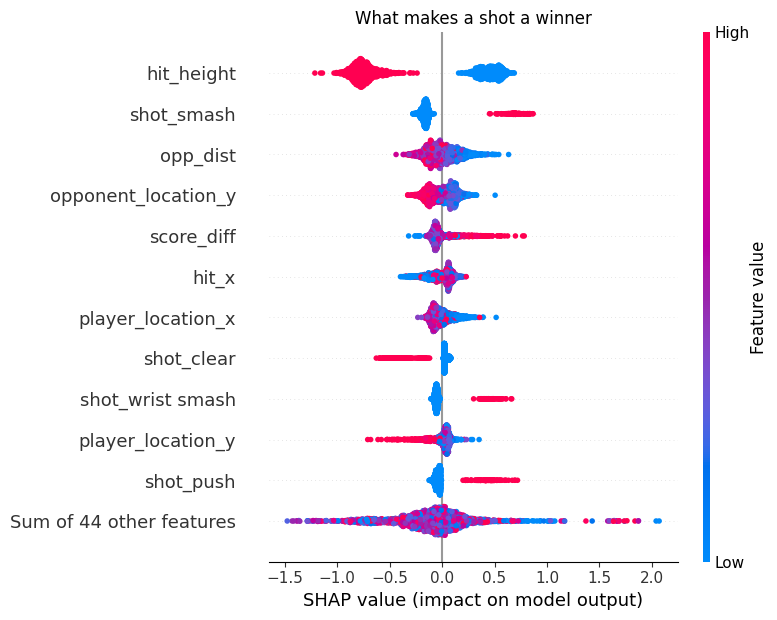

In [13]:
!pip install shap -q

import shap
import matplotlib.pyplot as plt

sample = X_test.sample(2000, random_state=0).astype(float)
explainer = shap.TreeExplainer(xgb3)
shap_values = explainer(sample)

shap.plots.beeswarm(shap_values[:, :, 1], max_display=12, show=False)
plt.title("What makes a shot a winner")
plt.tight_layout()
plt.savefig("shap_winner.png", dpi=150)
plt.show()

In [14]:
import json
from google.colab import files

# 1. the trained model
xgb3.save_model("rallyiq_model.json")

# 2. the exact feature columns, in order
with open("feature_columns.json", "w") as f:
    json.dump(list(X.columns), f)

# 3. which shots are realistic from each court zone
usage.to_csv("shot_usage.csv")

# 4. the shot-by-shot data for the app to replay
info_cols = ["match", "set", "rally", "rally_id", "ball_round", "player", "shot",
             "hit_area", "landing_x", "landing_y", "outcome", "rally_winner"]
app_data = pd.concat([strokes[info_cols], X], axis=1)
app_data["is_test"] = app_data.index.isin(X_test.index)
app_data.to_csv("rallies.csv.gz", index=False)

print(app_data.shape)

for name in ["rallyiq_model.json", "feature_columns.json", "shot_usage.csv", "rallies.csv.gz", "shap_winner.png"]:
    files.download(name)

(81403, 68)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>